# Indian Retail Sales — Data Cleaning & Feature Engineering

**Business context:** A multi-region Indian retail chain wants to understand where it's
losing profit and which regions/segments deserve more investment.

**Source data:** [Indian Store Data (Kaggle)](https://www.kaggle.com/datasets/abuhumzakhan/store-data)
— ~100K transactions, 2019–2023, sales/profit in INR, with region/state/city-tier fields.
*(This notebook currently runs against a small synthetic sample with the same schema —
see `data/raw/README.md`. Swap in the real CSV before drawing final conclusions.)*

**This notebook:**
1. Loads and audits the raw data
2. Cleans nulls, duplicates, and inconsistent date formats
3. Engineers analysis-ready columns (profit margin, delivery time, order period)
4. Splits the flat file into a normalized `customers` / `products` / `orders` schema for SQL


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
RAW_PATH = "../data/raw/indian_store_data.csv"
df = pd.read_csv(RAW_PATH)
df = df.rename(columns={"Category of Goods": "Category"})
print(df.shape)
df.head()

(100000, 25)


,Customer ID,Customer Name,Last Name,Date of Birth,Sales,Year,Outlet Type,City Type,Category,Region,...,Ship Date,Ship Mode,State,Postal Code,Product ID,Sub-Category,Product Name,Quantity,Discount,Profit
0,CUST000001,Curtis,Krause,1973-11-29,3344.69,2023,Large,Tier 1,Fast Food,East,...,2020-04-18,Same Day,West Bengal,700001,PROD000001,Burgers,Burgers - 718,3,0.09,448.24
1,CUST000002,Jeremy,Foster,1987-08-30,37094.41,2022,Medium,Tier 2,Fast Food,East,...,2021-01-11,Standard Class,Punjab,160001,PROD000002,Pizzas,Pizzas - 519,5,0.39,3134.34
2,CUST000003,Ariel,Mccann,1980-12-15,35501.08,2023,Large,Village,Electric Appliances,South,...,2020-08-16,Second Class,Gujarat,380001,PROD000003,Fans,Fans - 395,6,0.07,8324.21
3,CUST000004,Colleen,Maynard,1989-05-23,8969.33,2021,Medium,Village,Dairy Products,East,...,2021-10-16,First Class,West Bengal,700001,PROD000004,Milk,Milk - 798,4,0.18,1962.66
4,CUST000005,Gina,Holden,1957-12-31,35530.44,2021,Small,Village,Sessional Fruits & Vegetables,West,...,2019-01-25,Standard Class,Delhi,110001,PROD000005,Tomatoes,Tomatoes - 442,4,0.27,2843.93


## 1. Data quality audit

In [2]:
print("Nulls per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nFully-null rows:", df.isna().all(axis=1).sum())
print("Exact duplicate rows:", df.duplicated().sum())
print("\nDtypes:")
print(df.dtypes)

Nulls per column:
Series([], dtype: int64)

Fully-null rows: 0


Exact duplicate rows: 0

Dtypes:
Customer ID       object
Customer Name     object
Last Name         object
Date of Birth     object
Sales            float64
Year               int64
Outlet Type       object
City Type         object
Category          object
Region            object
Country           object
Segment           object
Sales Date        object
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
State             object
Postal Code        int64
Product ID        object
Sub-Category      object
Product Name      object
Quantity           int64
Discount         float64
Profit           float64
dtype: object


## 2. Clean

- Drop fully-null rows (blank export artifacts)
- Drop exact duplicate rows
- Parse `Order Date` / `Ship Date` — the raw export mixes `DD-MM-YYYY` and `YYYY/MM/DD`
- Impute missing `Ship Mode` with the column mode; flag missing `Postal Code` rather than dropping (postal code isn't needed for the regional analysis)


In [3]:
df = df.dropna(how="all").drop_duplicates().reset_index(drop=True)

def parse_mixed_date(s):
    return pd.to_datetime(s, dayfirst=True, errors="coerce")

df["Order Date"] = parse_mixed_date(df["Order Date"])
df["Ship Date"] = parse_mixed_date(df["Ship Date"])

df["Ship Mode"] = df["Ship Mode"].fillna(df["Ship Mode"].mode()[0])
df["Postal Code Missing"] = df["Postal Code"].isna()

# rows where date parsing failed or core business fields are missing aren't usable
before = len(df)
df = df.dropna(subset=["Order Date", "Ship Date", "Sales", "Profit", "Region"])
print(f"Dropped {before - len(df)} unusable rows after date/field cleaning")
print(df.shape)

Dropped 0 unusable rows after date/field cleaning
(100000, 26)


/tmp/ipykernel_133307/1129580805.py:4: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(s, dayfirst=True, errors="coerce")
/tmp/ipykernel_133307/1129580805.py:4: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(s, dayfirst=True, errors="coerce")


## 3. Feature engineering

In [4]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]).round(4)
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

df[["Sales", "Profit", "Profit Margin", "Delivery Days", "Order Quarter"]].describe(include="all")

,Sales,Profit,Profit Margin,Delivery Days,Order Quarter
count,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,NaN,NaN,NaN,NaN,20
top,NaN,NaN,NaN,NaN,2019Q3
freq,NaN,NaN,NaN,NaN,5117
mean,25084.410142,3755.305114,0.149651,3.991060,NaN
std,14403.187686,2639.852035,0.052594,2.006554,NaN
min,100.570000,6.520000,0.050000,1.000000,NaN
25%,12618.030000,1651.105000,0.107900,2.000000,NaN
50%,25134.695000,3317.450000,0.143900,4.000000,NaN
75%,37575.850000,5363.845000,0.185625,6.000000,NaN


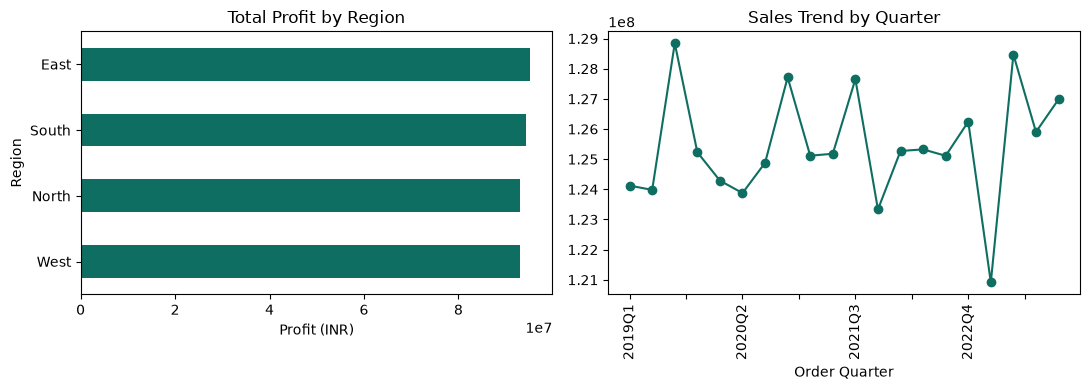

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby("Region")["Profit"].sum().sort_values().plot(kind="barh", ax=axes[0], color="#0F6E62")
axes[0].set_title("Total Profit by Region")
axes[0].set_xlabel("Profit (INR)")

df.groupby("Order Quarter")["Sales"].sum().plot(ax=axes[1], color="#0F6E62", marker="o")
axes[1].set_title("Sales Trend by Quarter")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("../dashboard/eda_preview.png", dpi=110)
plt.show()

## 4. Normalize into a relational schema

Splitting the flat export into `customers`, `products`, and `orders` mirrors how this data
would actually live in a production database, and is what lets the SQL step demonstrate real
joins rather than querying one denormalized table.


In [6]:
customers = (
    df[["Customer ID", "Customer Name", "Last Name", "Segment", "City Type", "Region", "State"]]
    .drop_duplicates(subset="Customer ID")
    .reset_index(drop=True)
)

products = (
    df[["Category", "Sub-Category"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
products.insert(0, "Product ID", ["PROD-%04d" % i for i in range(1, len(products) + 1)])

df = df.drop(columns=["Product ID", "Product Name"], errors="ignore")

orders = df.merge(products, on=["Category", "Sub-Category"], how="left")[[
    "Order ID", "Customer ID", "Product ID", "Order Date", "Ship Date", "Ship Mode",
    "Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Delivery Days",
    "Order Year", "Order Month", "Order Quarter", "Postal Code Missing",
]]

print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

def to_snake_case(columns):
    return [c.strip().lower().replace(" ", "_").replace("-", "_") for c in columns]

customers.columns = to_snake_case(customers.columns)
products.columns = to_snake_case(products.columns)
orders.columns = to_snake_case(orders.columns)

customers.to_csv("../data/processed/customers.csv", index=False)
products.to_csv("../data/processed/products.csv", index=False)
orders.to_csv("../data/processed/orders.csv", index=False)
print("Saved cleaned tables to data/processed/ (snake_case columns, matching sql/01_schema.sql)")

customers: (100000, 7) | products: (24, 3) | orders: (100000, 16)


Saved cleaned tables to data/processed/ (snake_case columns, matching sql/01_schema.sql)


## Next step

Load `customers.csv`, `products.csv`, and `orders.csv` into PostgreSQL using `sql/01_schema.sql`,
then run the analysis queries in `sql/02_business_queries.sql`.
